In [1]:
import numpyro
numpyro.set_host_device_count(1)

import numpy as np
import matplotlib.pyplot as plt
import scienceplots

from scipy.stats import norm
import candel

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
config_path = "/Users/rstiskalek/Projects/CANDEL/scripts/runs/config_CCHP.toml"
data = candel.pvdata.load_CCHP_from_config(config_path, )
model = candel.model.CCHPTRGBModel(config_path, data)

In [3]:
samples = candel.run_H0_inference(model)

2025-12-15 22:24:35 running inference on devices: cpu(cpu)
2025-12-15 22:24:35 using NumPyro platform: CPU


warmup:   4%|▎         | 72/2000 [02:56<1:18:41,  2.45s/it, 1023 steps of size 5.34e-04. acc. prob=0.73]


KeyboardInterrupt: 

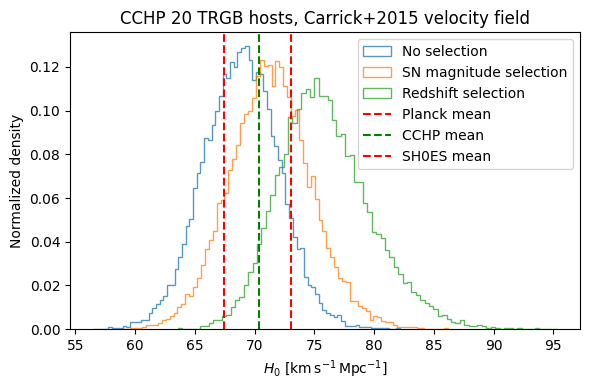

In [23]:
H0_nosel = candel.util.read_samples("", "/Users/rstiskalek/Projects/CANDEL/results/CCHP/test_nosel.hdf5", "H0")
H0_SNsel = candel.util.read_samples("", "/Users/rstiskalek/Projects/CANDEL/results/CCHP/test_SNsel.hdf5", "H0")
H0_redshift = candel.util.read_samples("", "/Users/rstiskalek/Projects/CANDEL/results/CCHP/test_redshiftsel.hdf5", "H0")


fig, ax = plt.subplots(figsize=(6, 4),)

ax.set_title("CCHP 20 TRGB hosts, Carrick+2015 velocity field")

ax.hist(
    H0_nosel, bins="auto", density=True, histtype="step",
    label="No selection", alpha=0.75)
ax.hist(
    H0_SNsel, bins="auto", density=True, histtype="step",
    label="SN magnitude selection", alpha=0.75)
ax.hist(
    H0_redshift, bins="auto", density=True, histtype="step",
    label="Redshift selection", alpha=0.75)

ax.axvline(67.4, color="red", linestyle="--", label="Planck mean")
ax.axvline(70.4, color="green", linestyle="--", label="CCHP mean")
ax.axvline(73.04, color="red", linestyle="--", label="SH0ES mean")

ax.set_xlabel(r"$H_0~[\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}]$")
ax.set_ylabel("Normalized density")
ax.legend()

plt.tight_layout()
fig.savefig("/Users/rstiskalek/Downloads/H0_samples.png", bbox_inches="tight", dpi=450)
plt.show()

In [14]:
from scipy.stats import norm
import posterior_agreement


H0 = norm(69.1, 1.2).rvs(50_000)
# H0_test = norm(67.4, 0.5).rvs(50000)
H0_test = norm(73.04, 1.04).rvs(50000)



chains = (H0, H0_test)
agreement_1d = posterior_agreement.compute_agreement(chains)

print("p-value %.3f, corresponding to %.4f sigmas"%(agreement_1d.PTE, agreement_1d.sigma))

p-value 0.011, corresponding to 2.5368 sigmas


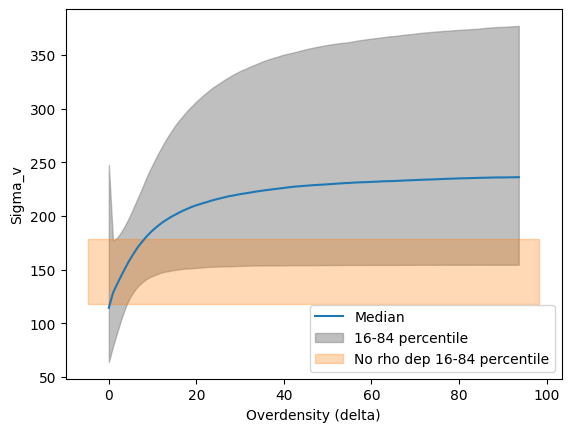

In [20]:
from jax import numpy as jnp


def sigma_v_from_density(delta, sigma_v_low, sigma_v_high,
                         log_rho_t, k):
    """Map overdensity to sigma_v through a sigmoid in log density."""
    rho = jnp.clip(1.0 + delta, a_min=1e-6)
    log_rho = jnp.log(rho)
    return sigma_v_low + (sigma_v_high - sigma_v_low) / (
        1.0 + jnp.exp(-k * (log_rho - log_rho_t)))

sigma_v_low = 80
sigma_v_high = 700
log_rho_t = 1.9
k = 1.2


# fname = "/Users/rstiskalek/Projects/CANDEL/results/CH0/CH0_beta_1.0_sel-SN_magnitude_redshift_manticore_2MPP_MULTIBIN_N256_DES_V2_sigv_rho.hdf5"
# fname_no_rho_dep = "/Users/rstiskalek/Projects/CANDEL/results/CH0/CH0_beta_1.0_sel-SN_magnitude_redshift_manticore_2MPP_MULTIBIN_N256_DES_V2.hdf5"

fname = "/Users/rstiskalek/Projects/CANDEL/results/CH0/CH0_beta_1.0_sel-redshift_manticore_2MPP_MULTIBIN_N256_DES_V2_sigv_rho.hdf5"
fname_no_rho_dep = "/Users/rstiskalek/Projects/CANDEL/results/CH0/CH0_beta_1.0_sel-SN_magnitude_redshift_manticore_2MPP_MULTIBIN_N256_DES_V2.hdf5"

from h5py import File

with File(fname, 'r') as f:
    grp = f['samples']
    sigma_v_low = grp['sigma_v_low'][:]
    sigma_v_high = grp['sigma_v_high'][:]
    log_rho_t = grp['log_sigma_v_rho_t'][:]
    k = grp['sigma_v_k'][:]

with File(fname_no_rho_dep, 'r') as f:
    grp = f['samples']
    sigma_v_no_rho_dep = grp['sigma_v'][:]


delta = jnp.linspace(-1, 300.0, 100)
sigma_v = sigma_v_from_density(delta[:, None], sigma_v_low[None, :], sigma_v_high[None, :], log_rho_t[None, :], k[None, :])

ylow, ymed, yhigh = np.percentile(sigma_v, [16, 50, 84], axis=1)

plt.figure()

plt.plot((1 + delta) * 0.3111, ymed, label='Median')
plt.fill_between((1 + delta) * 0.3111, ylow, yhigh, color='gray', alpha=0.5, label='16-84 percentile')

ylow, yhigh = np.percentile(sigma_v_no_rho_dep, [16, 84])
xlim = plt.xlim()
plt.fill_between(xlim, ylow, yhigh, color='C1', alpha=0.3, label='No rho dep 16-84 percentile')





plt.xlabel('Overdensity (delta)')
plt.ylabel('Sigma_v')
plt.legend()
plt.show()

In [18]:
ylow, yhigh

(117.92885070800781, 178.39974487304687)

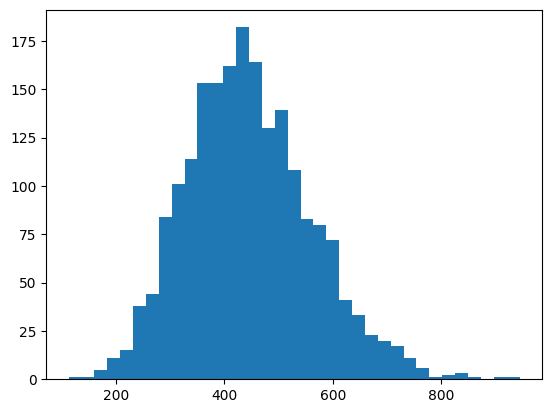

In [44]:
plt.figure()
plt.hist(sigma_v_high, bins="auto")
plt.show()

In [30]:
rho = np.load("/Users/rstiskalek/Projects/CANDEL/data/fields/carrick2015_twompp_density.npy")

In [33]:
rho = 1 + rho.reshape(-1,)

rho = rho[rho > 0]  # remove extreme voids

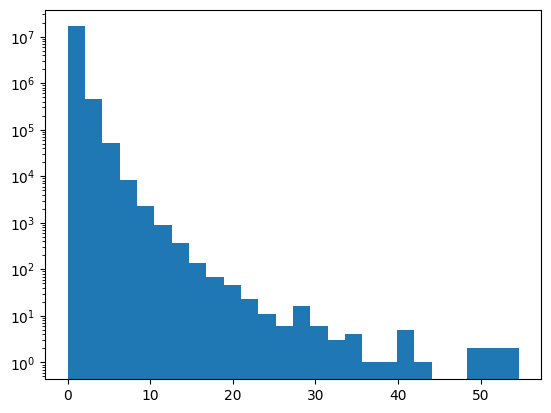

In [36]:
plt.figure()
plt.hist(rho, bins="auto")
plt.yscale("log")
plt.show()